In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o",
)

small_llm = ChatOpenAI(
    model="gpt-4o-mini",
)

In [3]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """숫자 a와 b를 더합니다."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a와 b를 곱합니다."""
    return a * b

간단한 웹 검색 도구 활용 

In [4]:
# %pip install -U ddgs

In [5]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()

In [6]:
# %pip install -qU langchain-google-community\[gmail\]

In [7]:
from langchain_google_community import GmailToolkit

from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)

# Can review scopes here https://developers.google.com/gmail/api/auth/scopes
# For instance, readonly scope is 'https://www.googleapis.com/auth/gmail.readonly'
# 참고: 라이브러리 파라미터명이 client_sercret_file (오타)로 되어 있음
credentials = get_gmail_credentials(
    token_file="./google/gmail_token.json",
    scopes=["https://mail.google.com/"],
    client_sercret_file="./google/gmail_credentials.json",
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)
gmail_tool_list = gmail_toolkit.get_tools()


/var/folders/rb/wylmzgk90lb3vbd81tm_qck00000gn/T/ipykernel_15320/3036984763.py:11: DeprecationWarning: get_gmail_credentials is deprecated and will be removed in a future version.Use get_google_credentials instead.
  credentials = get_gmail_credentials(
/var/folders/rb/wylmzgk90lb3vbd81tm_qck00000gn/T/ipykernel_15320/3036984763.py:16: DeprecationWarning: build_resource_service is deprecated and will be removed in a future version.Use build_gmail_service instead.
  api_resource = build_resource_service(credentials=credentials)


In [8]:
gmail_tool_list

[GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x1139ce3c0>),
 GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x1139ce3c0>),
 GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x1139ce3c0>),
 GmailGetMessage(api_resource=<googleapiclient.discovery.Resource object at 0x1139ce3c0>),
 GmailGetThread(api_resource=<googleapiclient.discovery.Resource object at 0x1139ce3c0>)]

In [9]:
#%pip install langchain-community arxiv

In [10]:
# 최신 LangChain에서는 load_tools가 langchain_community로 이동함
from langchain_community.agent_toolkits.load_tools import load_tools

loaded_tool_list = load_tools(
    ["arxiv"],
)


In [11]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.tools.retriever import create_retriever_tool

embedding_function = OpenAIEmbeddings(
    model='text-embedding-3-large',
)
vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name = 'real_estate_tax',
    persist_directory='./real_estate_tax_collection'
)
retriever = vector_store.as_retriever(search_kwargs={'k': 3})
retriever_tool = create_retriever_tool(
    retriever=retriever,
    name='real_estate_tax_retriever',
    description='Contains information about real estate tax up to December 2024',
)

In [12]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply, search_tool, retriever_tool] + gmail_tool_list + loaded_tool_list
llm_with_tools = small_llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [13]:
from langgraph.graph import MessagesState, StateGraph

graph_builder = StateGraph(MessagesState)

In [14]:
def agent(state: MessagesState) -> MessagesState:
    """
    에이전트 함수는 주어진 상태에서 메시지를 가져와
    LLM과 도구를 사용하여 응답 메시지를 생성합니다.

    Args:
        state (MessagesState): 메시지 상태를 포함하는 state.

    Returns:
        MessagesState: 응답 메시지를 포함하는 새로운 state.
    """
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

In [15]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)

In [16]:
from langgraph.graph import START, END
from langgraph.prebuilt import tools_condition


graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    tools_condition
)
graph_builder.add_edge('tools', 'agent')

In [17]:
graph= graph_builder.compile()

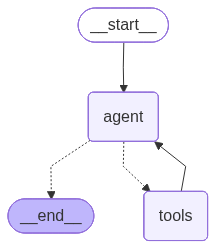

In [18]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
from langchain_core.messages import HumanMessage

query = '집이 15억일때 부동산 세를 계산해 줄 수 있나요?'
for chunk in graph.stream({'messages': [HumanMessage(query)]}, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

집이 15억일때 부동산 세를 계산해 줄 수 있나요?
================================== Ai Message ==================================
Tool Calls:
  real_estate_tax_retriever (call_4hS3oqh07qwiwzJu8WJmHMvU)
 Call ID: call_4hS3oqh07qwiwzJu8WJmHMvU
  Args:
    query: 15억
================================= Tool Message =================================
Name: real_estate_tax_retriever

종합부동산세법
[시행 2023. 4. 18] [법률 제19342호, 2023. 4. 18, 일부개정]
기획재정부 (재산세제과) 044-215-4313
제1장 총칙
제1조(목적) 이 법은 고액의 부동산 보유자에 대하여 종합부동산세를 부과하여 부동산보유에 대한 조세부담의 형평성을 제고하고, 부동산의 가격안정을 도모함으로써 지방재정의 균형발전과 국민경제의 건전한 발전에 이바지함을 목적으로 한다.
제2조(정의) 이 법에서 사용하는 용어의 정의는 다음 각호와 같다. <개정 2005. 12. 31., 2010. 3. 31., 2016. 1. 19., 2018. 12. 31., 2020. 6. 9., 2023. 3. 14.>
1. "시·군·구"란 함은 「지방자치법」 제2조에 따른 지방자치단체인 시·군 및 자치구(이하 "시·군·구"이라 한다)를 말한다.
2. "시장·군수·구청장"이라 함은 지방자치단체의 장인 시장·군수 및 자치구의 구청장(이하 "시장·군수·구청장"이라 한다)를 말한다.
3. "주택"이라 함은 「지방세법」 제104조제3호에 의한 주택을 말한다.
4. "토지"라 함은 「지방세법」 제104